In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, make_scorer
from sklearn.preprocessing import StandardScaler

In [ ]:
file_path = '/content/drive/MyDrive/DF_2026_Demo/dataset_sample.csv'
df = pd.read_csv(file_path)
print("Data preview:")
print(df.head())

Data preview:
          X1         X2         X3         X4          X5           X6   Y1
0  34.400423  13.208689   7.643646  13.251368  117.996835  -299.610602  460
1  35.960094   10.05798  17.976625   8.107629  121.996835  -299.610602  440
2   32.14675   7.736695   24.90996   3.678209  125.996835  -299.610602  400
3  28.384832   7.109847  33.460369  11.430173  129.996835  -299.610602  350
4  24.697851   8.558236  32.951069  16.608829  133.996835  -299.610602  300


In [ ]:
# Convert all columns to numeric (non-convertible values become NaN)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with NaN and reset the index
df = df.dropna().reset_index(drop=True)

# Define features and target
X = df[["X1", "X2", "X3", "X4", "X5", "X6"]].values
y = df["Y1"].values

In [ ]:
# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Print shapes of training and testing sets
print("\nShapes of training and testing sets:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


Shapes of training and testing sets:
X_train shape: (5032, 6)
y_train shape: (5032,)
X_test shape: (1258, 6)
y_test shape: (1258,)


In [ ]:
# Random Forest is scale-invariant, so we deliberately do NOT scale the features.
# The model below is trained on the RAW features, which means the exported ONNX
# package also receives RAW features — there is no scaler to reproduce downstream.
# (Lecture: "don't add a scaler just because the notebook once computed one —
#  package the path the model actually used.")

In [ ]:
# Define a parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None], # Wrap 'None' in a list
    'min_samples_split': [10], # Wrap '10' in a list for consistency, though not strictly necessary for single integers
    'min_samples_leaf': [4, 6]
}

# Create the base Random Forest model
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Set up the grid search with 5-fold cross-validation using R² as the scoring metric
grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           cv=5,
                           scoring='r2',
                           verbose=2,
                           n_jobs=-1)

# Run grid search on the training data
grid_search.fit(X_train, y_train)

# Display the best parameters found by grid search
print("Best parameters:", grid_search.best_params_)

# Use the best estimator from grid search
best_rf = grid_search.best_estimator_

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameters: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


Random Forest Regressor Results with best parameters:
Training R²: 0.8780566419388884
Training MAE: 46.52284724327887
Training MSE: 3779.544793131364
Test R²: 0.7261375023229244
Test MAE: 71.19562805919352
Test MSE: 8506.202794518109


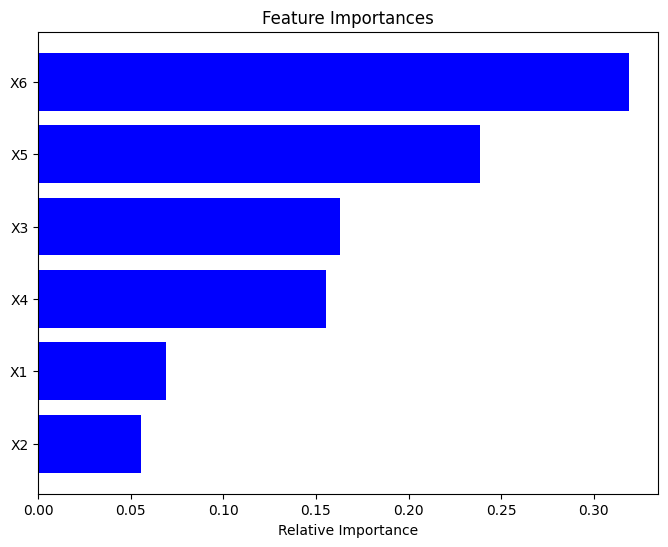

In [ ]:
# Evaluate on the training set
y_train_pred = best_rf.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)  # Calculate training MAE
mse_train = mean_squared_error(y_train, y_train_pred)  # Calculate training MSE

# Evaluate on the test set
y_test_pred = best_rf.predict(X_test)
r2_test = r2_score(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print("Random Forest Regressor Results with best parameters:")
print("Training R²:", r2_train)
print("Training MAE:", mae_train)  # Print training MAE
print("Training MSE:", mse_train)  # Print training MSE
print("Test R²:", r2_test)
print("Test MAE:", mae_test)
print("Test MSE:", mse_test)

# ... (rest of the code remains the same) ...

# Plot feature importances
importances = best_rf.feature_importances_
features = ["X1", "X2", "X3", "X4", "X5", "X6"]
indices = np.argsort(importances)

plt.figure(figsize=(8, 6))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

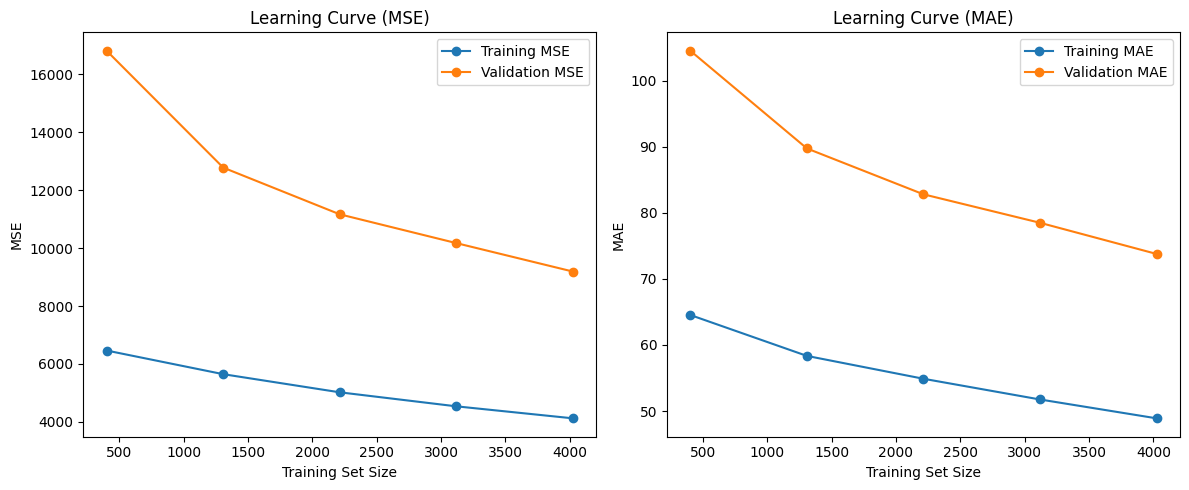

In [ ]:
# 8) Learning Curves for MSE and MAE
#    We use learning_curve to visualize how the model performs as the
#    training set size increases.

from sklearn.model_selection import learning_curve

# --- MSE Learning Curve ---
train_sizes_mse, train_scores_mse, val_scores_mse = learning_curve(
    estimator=best_rf,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='neg_mean_squared_error',  # use negative MSE (higher is better)
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),  # 5 points from 10% to 100% of training data
)

# Convert from negative MSE to MSE
train_mse_mean = -np.mean(train_scores_mse, axis=1)
val_mse_mean = -np.mean(val_scores_mse, axis=1)

# --- MAE Learning Curve ---
train_sizes_mae, train_scores_mae, val_scores_mae = learning_curve(
    estimator=best_rf,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='neg_mean_absolute_error',  # use negative MAE (higher is better)
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Convert from negative MAE to MAE
train_mae_mean = -np.mean(train_scores_mae, axis=1)
val_mae_mean = -np.mean(val_scores_mae, axis=1)

# 9) Plot the learning curves: MSE and MAE
plt.figure(figsize=(12, 5))

# Plot MSE
plt.subplot(1, 2, 1)
plt.plot(train_sizes_mse, train_mse_mean, 'o-', label='Training MSE')
plt.plot(train_sizes_mse, val_mse_mean, 'o-', label='Validation MSE')
plt.xlabel('Training Set Size')
plt.ylabel('MSE')
plt.title('Learning Curve (MSE)')
plt.legend()

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(train_sizes_mae, train_mae_mean, 'o-', label='Training MAE')
plt.plot(train_sizes_mae, val_mae_mean, 'o-', label='Validation MAE')
plt.xlabel('Training Set Size')
plt.ylabel('MAE')
plt.title('Learning Curve (MAE)')
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
!pip install onnx
!pip install skl2onnx

In [24]:
import onnx
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import os

# Assuming 'best_rf' is your trained RandomForestRegressor model
# and 'file_path' points to your CSV file.

# Get the directory of the dataset
dataset_dir = os.path.dirname(file_path)

# Define the initial type for the input data
initial_type = [('float_input', FloatTensorType([None, 6]))]  # 6 features

# Convert the model to ONNX format
onnx_model = convert_sklearn(best_rf, initial_types=initial_type,target_opset=9)

# Save the ONNX model to the dataset directory
onnx_file_path = os.path.join(dataset_dir, "rf_model.onnx")
onnx.save_model(onnx_model, onnx_file_path)

print(f"ONNX model saved to: {onnx_file_path}")


ONNX model saved to: /content/drive/MyDrive/DF_2026_Demo/rf_model.onnx


## Validate the export and ship the contract

Generating a `.onnx` file is not a working deployment. We now (1) compare native scikit-learn vs. ONNX Runtime predictions with a tolerance, and (2) write a manifest with the I/O contract, training range, SHA-256 checksum, and golden cases.

In [25]:
# --- Validate: native scikit-learn vs ONNX Runtime (golden cases) ---
!pip install -q onnxruntime
import onnxruntime as ort
import json, hashlib

feature_names = ["X1", "X2", "X3", "X4", "X5", "X6"]
n_gold = 5
X_gold = X_test[:n_gold].astype(np.float32)   # X_test is RAW (RF trained on raw features)

native_pred = best_rf.predict(X_gold).ravel()

sess    = ort.InferenceSession(onnx_file_path, providers=["CPUExecutionProvider"])
in_name = sess.get_inputs()[0].name
onnx_pred = np.array(sess.run(None, {in_name: X_gold})[0]).ravel()

print("native:", np.round(native_pred, 4))
print("onnx:  ", np.round(onnx_pred, 4))
max_abs_diff = float(np.max(np.abs(native_pred - onnx_pred)))
print("max |native - onnx| =", max_abs_diff)
assert max_abs_diff < 1e-2, "ONNX export does NOT match the trained model!"
print("✅ ONNX matches the native model within tolerance.")

native: [103.6444 191.1487 117.6284 526.5399 517.7404]
onnx:   [103.6444 191.1487 117.6284 526.5398 517.7404]
max |native - onnx| = 9.824051812756807e-05
✅ ONNX matches the native model within tolerance.


In [26]:
# --- Ship the CONTRACT, not just the file: manifest + golden cases + checksum ---
X_all_raw = df[feature_names].values

def sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

golden_cases = [
    {"input": X_gold[i].tolist(), "expected": float(onnx_pred[i]), "tolerance": 1e-2}
    for i in range(n_gold)
]

manifest = {
    "name": "rf_surrogate",
    "version": "1.0.0",
    "framework": "scikit-learn RandomForestRegressor -> onnx (skl2onnx)",
    "onnx_opset": 9,
    "model_file": os.path.basename(onnx_file_path),
    "sha256": sha256(onnx_file_path),
    "input": {
        "name": in_name,
        "dtype": "float32",
        "shape": [None, 6],
        "feature_order": feature_names,
        "preprocessing": "none — RAW features (Random Forest is scale-invariant)",
        "training_range": {
            n: [float(X_all_raw[:, i].min()), float(X_all_raw[:, i].max())]
            for i, n in enumerate(feature_names)
        },
    },
    "output": {"name": sess.get_outputs()[0].name, "meaning": "Y1 (regression target)"},
    "golden_cases": golden_cases,
}

manifest_path = os.path.join(dataset_dir, "rf_model_manifest.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)
print("Manifest saved to:", manifest_path)
print(json.dumps(manifest, indent=2))

Manifest saved to: /content/drive/MyDrive/DF_2026_Demo/rf_model_manifest.json
{
  "name": "rf_surrogate",
  "version": "1.0.0",
  "framework": "scikit-learn RandomForestRegressor -> onnx (skl2onnx)",
  "onnx_opset": 9,
  "model_file": "rf_model.onnx",
  "sha256": "f12914802aed440d12752c571a8be078d64dc03869cad53c056e1ccdac40dade",
  "input": {
    "name": "float_input",
    "dtype": "float32",
    "shape": [
      null,
      6
    ],
    "feature_order": [
      "X1",
      "X2",
      "X3",
      "X4",
      "X5",
      "X6"
    ],
    "preprocessing": "none \u2014 RAW features (Random Forest is scale-invariant)",
    "training_range": {
      "X1": [
        6.981573,
        59.863156
      ],
      "X2": [
        1.485979,
        80.370284
      ],
      "X3": [
        0.0,
        66.53256
      ],
      "X4": [
        0.0,
        49.839784
      ],
      "X5": [
        -38.003165,
        197.996835
      ],
      "X6": [
        -299.610602,
        -111.610602
      ]
   